### Домашнее задание №2

### Описание:
Классифицировать игроков в каждом кадре по двум командам на основе цвета их формы.

### Данные:
Скачайте архив с данными [отсюда](https://disk.yandex.ru/d/NMlVHytktlzbEw) и распакуйте. Внутри архива лежит папка `frames` и файл `bboxes.json`. Файл `bboxes.json` содержит bounding boxes игроков двух команд, а в папке `frames` расположены соответствующие им изображения (кадры). Всего дано 100 кадров. Каждому кадру соответствует 10 bounding boxes игроков.

Структура файла `bboxes.json` следующая:
```
frame_n: {
     player_1: {
             'box': [x,y,w,h],
             'team': int
     }
     .....
     plyaer_10: { .... }
}
....
frame_n+k: { .... }
```
Здесь `frame_n` - номер кадра (ему соответствует файл с изображением в папке frames, всего 100),<br>
`player_1` - id игрока в текущем кадре,<br>
`'box': [x,y,w,h]` - bounding box соответствующего игрока (координаты нормализованы от 0 до 1, поэтому их нужно домножить на размеры изображения, чтобы перевести их в целые координаты фрейма),<br>
`'team': int` - id команды к которой принадлежит игрок  в данном кадре (может принимать значения 0 или 1).
Такм образом, id игроков и id команд имеют смысл только в пределах одного кадра и не связаны с другими кадрами. Т.е. в разных кадрах одному и тому же игроку / команде может соответствовать разные id.

### Задачи:
1) Классифицируйте игроков, используя в качестве вектора признаков игрока (features) средний цвет в пространстве RGB, который берется из области изображения, покрытой bounding box этого игрока (т.е. вектор признаков будет состоять из 3 элементов `[r,g,b]`.<br>
2) Используйте в качестве вектора признаков игроков их средний цвет в пространстве HSV (аналогично вектор признаков `[h,s,v]`.<br>
3) Используйте в качестве вектора признаков гистограмму в пространстве RGB, а не средний цвет. Число бинов определите самостоятельно.<br>
4) Используйте в качестве вектора признаков гистограмму в пространстве HSV.

### Как классифицировать:
В качестве классификатора можете использовать:
- Методы без обучения: k-means (на 2 кластера) или другие методы кластеризации.
- Методы с обучением: K-Nearest Neighbors, RandomForest, GaussianNB или др.

### Результаты:
1. Посчитайте точность классификации для каждого варианта и сравните результаты.
2. Задание будет принято, если итоговая точность будет выше чем 0.5
3. [опционально] При тестировании на закрытой выборке в конце курса будет подведен итог (рекорд по всем курсам на данный момент - ***0.953***).

#### Полезные советы
- Боксы игроков имеют разный размер, поэтому нормализуйте гистограмму перед ее использованием в качестве вектора признаков (делите значения гистограммы на площадь бокса).
- Большое число бинов гистограммы может привести к худшим результатам, поэтому попробуйте использовать 8/16/32.
- Для построения вектора признаков лучше использовать некоторую его центральную область, т.к. она покрывает игрока, а границы часто содержут фон / других игроков.

In [1]:
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import rgb_to_hsv
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

DATA_DIR = "team_classification_data"
FRAMES_DIR = os.path.join(DATA_DIR, "frames")
BBOXES_PATH = os.path.join(DATA_DIR, "bboxes.json")

with open(BBOXES_PATH, "r") as f:
    bboxes = json.load(f)

print(f"Количество изображений: {len(bboxes)}")

Количество изображений: 100


## Функция для получения кропа с изображением игрока

Края bbox часто содержат фон или соседних игроков, поэтому вырезаем не весь bbox, а его центральную область — обрезаем по `CROP_MARGIN` с каждой стороны по ширине и высоте.

In [2]:
CROP_MARGIN = 0.3


def get_player_crop(image, box, margin=CROP_MARGIN):
    H, W = image.shape[:2]
    x, y, w, h = box
    x, y = x + w * margin, y + h * margin
    w, h = w * (1 - 2 * margin), h * (1 - 2 * margin)
    x1 = int(round(x * W))
    y1 = int(round(y * H))
    x2 = int(round((x + w) * W))
    y2 = int(round((y + h) * H))
    x1, x2 = np.clip([x1, x2], 0, W)
    y1, y2 = np.clip([y1, y2], 0, H)
    x2, y2 = max(x2, x1 + 1), max(y2, y1 + 1)
    return image[y1:y2, x1:x2]

## Признаки (задачи 1-4)

- **Mean RGB** / **Mean HSV** — средний цвет по всем пикселям кропа в соответствующем пространстве (вектор из 3 чисел).
- **Histogram RGB** / **Histogram HSV** — гистограммы по `N_BINS = 8` бинов на каждый из 3 каналов, склеенные в один вектор из 24 чисел. Нормируются делением на площадь кропа (число пикселей), чтобы боксы разного размера были сопоставимы.

HSV получаем через `matplotlib.colors.rgb_to_hsv` (вход и выход в диапазоне `[0, 1]`).

In [3]:
N_BINS = 8  # количество интервалов гистограммы для каждого цветового канала при вычислении гистограммных признаков


def feat_mean_rgb(crop):
    return crop.reshape(-1, 3).mean(axis=0)


def feat_mean_hsv(crop):
    hsv = rgb_to_hsv(crop / 255.0)
    return hsv.reshape(-1, 3).mean(axis=0)


def feat_hist_rgb(crop, bins=N_BINS):
    pixels = crop.reshape(-1, 3)
    area = pixels.shape[0]
    hists = [np.histogram(pixels[:, c], bins=bins, range=(0, 255))[0] for c in range(3)]
    return np.concatenate(hists).astype(float) / area


def feat_hist_hsv(crop, bins=N_BINS):
    hsv = rgb_to_hsv(crop / 255.0).reshape(-1, 3)
    area = hsv.shape[0]
    hists = [np.histogram(hsv[:, c], bins=bins, range=(0, 1))[0] for c in range(3)]
    return np.concatenate(hists).astype(float) / area


FEATURE_FUNCS = {
    "Mean RGB": feat_mean_rgb,
    "Mean HSV": feat_mean_hsv,
    "Histogram RGB": feat_hist_rgb,
    "Histogram HSV": feat_hist_hsv,
}

## Загрузка кадров и вырезка bbox-областей игроков

Кропы вычисляются один раз на кадр и переиспользуются для всех 4 типов признаков.

In [4]:
frame_ids = sorted(bboxes.keys(), key=int)

frame_data = []
for frame_id in frame_ids:
    image = np.array(Image.open(os.path.join(FRAMES_DIR, f"{frame_id}.jpeg")).convert("RGB"))
    players = bboxes[frame_id]
    crops, teams = [], []
    for player_id in sorted(players.keys(), key=int):
        p = players[player_id]
        crops.append(get_player_crop(image, p["box"]))
        teams.append(p["team"])
    frame_data.append({"crops": crops, "teams": np.array(teams)})

print(f"Loaded {len(frame_data)} frames, {len(frame_data[0]['teams'])} players each")

Loaded 100 frames, 10 players each


## Кластеризация (k-means, k=2) и метрики качества

Признаки нормализуются с помощью `StandardScaler` перед k-means, чтобы разные каналы/бины вносили сопоставимый вклад в расстояние. Кластеризация и подсчёт точности выполняются отдельно для каждого кадра.

K-means присваивает кластерам произвольные метки `0`/`1`, никак не связанные с реальными id команд — поэтому точность считается как `max(acc, 1 - acc)`: лучшее из двух возможных сопоставлений кластеров с истинными командами.

In [5]:
def cluster_accuracy(true_labels, pred_labels):
    acc = accuracy_score(true_labels, pred_labels)
    return max(acc, 1 - acc)


def evaluate_feature_type(feature_fn, seed=0):
    accuracies = []
    for data in frame_data:
        features = np.stack([feature_fn(crop) for crop in data["crops"]])
        features = StandardScaler().fit_transform(features)
        pred = KMeans(n_clusters=2, n_init=10, random_state=seed).fit_predict(features)
        accuracies.append(cluster_accuracy(data["teams"], pred))
    return np.array(accuracies)


results = {}
for name, fn in FEATURE_FUNCS.items():
    accs = evaluate_feature_type(fn)
    results[name] = accs
    print(f"{name:>15}: mean accuracy = {accs.mean():.3f} (std {accs.std():.3f})")

       Mean RGB: mean accuracy = 0.896 (std 0.092)


       Mean HSV: mean accuracy = 0.815 (std 0.119)


  Histogram RGB: mean accuracy = 0.908 (std 0.091)


  Histogram HSV: mean accuracy = 0.854 (std 0.116)


## Результаты: сравнение точности четырёх типов признаков

In [6]:
summary = pd.DataFrame({
    "mean_accuracy": {k: v.mean() for k, v in results.items()},
    "std_accuracy": {k: v.std() for k, v in results.items()},
    "median_accuracy": {k: np.median(v) for k, v in results.items()},
    "worst_frame_accuracy": {k: v.min() for k, v in results.items()},
}).sort_values("mean_accuracy", ascending=False)
summary

,mean_accuracy,std_accuracy,median_accuracy,worst_frame_accuracy
Histogram RGB,0.908,0.091302,0.9,0.6
Mean RGB,0.896,0.091564,0.9,0.6
Histogram HSV,0.854,0.116121,0.9,0.5
Mean HSV,0.815,0.118638,0.8,0.5


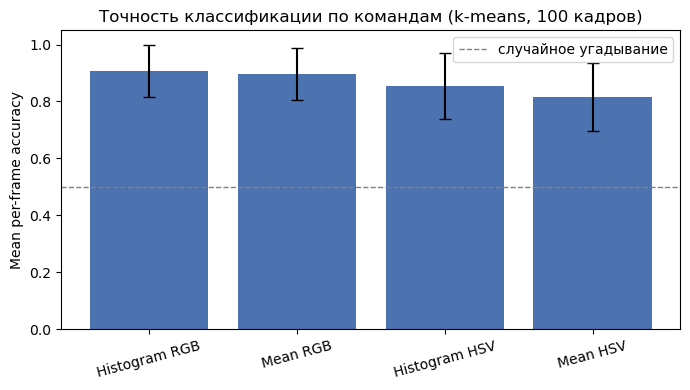

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
order = summary.index
ax.bar(order, summary["mean_accuracy"], yerr=summary["std_accuracy"], capsize=4, color="#4C72B0")
ax.set_ylabel("Mean per-frame accuracy")
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="случайное угадывание")
ax.set_title("Точность классификации по командам (k-means, 100 кадров)")
ax.legend()
for tick in ax.get_xticklabels():
    tick.set_rotation(15)
plt.tight_layout()
plt.show()

## Визуализация

Рамки закрашены цветом предсказанного k-means кластера (по признаку Mean RGB); подписи показывают истинный номер команды.

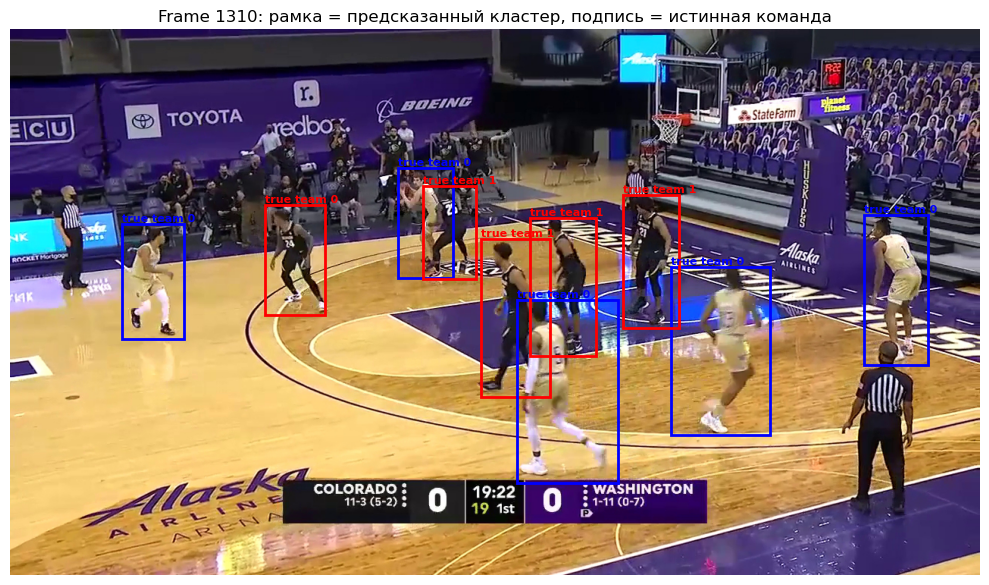

In [8]:
example_idx = 0
example_frame_id = frame_ids[example_idx]
data = frame_data[example_idx]

features = np.stack([feat_mean_rgb(crop) for crop in data["crops"]])
features_scaled = StandardScaler().fit_transform(features)
pred = KMeans(n_clusters=2, n_init=10, random_state=0).fit_predict(features_scaled)

image = np.array(Image.open(os.path.join(FRAMES_DIR, f"{example_frame_id}.jpeg")).convert("RGB"))
players = bboxes[example_frame_id]
player_ids = sorted(players.keys(), key=int)

cluster_colors = ["red", "blue"]
fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(image)
H, W = image.shape[:2]
for player_id, cluster in zip(player_ids, pred):
    x, y, w, h = players[player_id]["box"]
    rect = plt.Rectangle((x * W, y * H), w * W, h * H, fill=False,
                         edgecolor=cluster_colors[cluster], linewidth=2)
    ax.add_patch(rect)
    ax.text(x * W, y * H - 4, f"true team {players[player_id]['team']}",
            color=cluster_colors[cluster], fontsize=8, weight="bold")
ax.set_title(f"Frame {example_frame_id}: рамка = предсказанный кластер, подпись = истинная команда")
ax.axis("off")
plt.tight_layout()
plt.show()

## Выводы

Итоговая (усреднённая по 100 кадрам) точность k-means кластеризации по типам признаков:

| Признак | Mean accuracy | Std | Median | Worst frame |
|---|---|---|---|---|
| Histogram RGB | 0.908 | 0.091 | 0.9 | 0.6 |
| Mean RGB | 0.896 | 0.092 | 0.9 | 0.6 |
| Histogram HSV | 0.854 | 0.116 | 0.9 | 0.5 |
| Mean HSV | 0.815 | 0.119 | 0.8 | 0.5 |

(точные значения — в таблице `summary` выше).

- **Обрезка bbox до центральной области (`CROP_MARGIN = 0.3`) резко подняла точность всех признаков** — например, Mean RGB выросла с ~0.70 (по всему bbox) до ~0.90. Края bbox действительно засорены фоном (газон) и соседними игроками, как и предполагает подсказка в условии задачи — обрезка их убирает и делает цветовой признак игрока намного чище.
- **RGB-признаки по-прежнему обгоняют HSV.** Даже после обрезки в кропе остаётся немного газона, который смещает канал Hue сильнее, чем каналы R/G/B — поэтому HSV-варианты уступают RGB-вариантам на ~5-8 пунктов точности.
- **После обрезки гистограмма обгоняет средний цвет** (Histogram RGB 0.908 > Mean RGB 0.896; Histogram HSV 0.854 > Mean HSV 0.815) — до обрезки было наоборот. Когда в кропе почти нет фона, гистограмма (24 числа, распределение цвета) действительно несёт больше полезной информации, чем среднее (3 числа), и лишняя размерность больше не вредит кластеризации на 10 точках.
- Худший случай (`worst_frame_accuracy`) поднялся с 0.5 до 0.6 у RGB-признаков — то есть даже на самых сложных кадрах кластеризация теперь работает чуть лучше случайного угадывания.